# 04a. Binary Classifier (Leakage-safe Gatekeeper)
This notebook trains the fault detection gatekeeper using leakage-safe splits and run-level rolling features.

- Run-level train/validation split using `run_key` (faultNumber + simulationRun).
- Pre-fault masking for faulty runs (sample <= 20 for train, <= 160 for test).
- Rolling features computed within each run before row sampling.
- Two training approaches:
  - Balanced (Momay): train 50/50 and val 50/50.
  - Imbalanced: train 90/10 with `class_weight="balanced"`, val 50/50.
- Test set is capped at 500,000 rows with 90/10 ratio.
- Threshold tuning is performed on each validation set and applied to the test set.


In [1]:
import gc
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score
 )

warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed").is_dir():
            return path
    raise FileNotFoundError("Could not find data/processed from current directory")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ROLLING_WINDOWS = [10, 20, 30, 50, 100]

TRAIN_ROWS_BAL = 400_000
VAL_ROWS_BAL = 100_000
TRAIN_NORMAL_BAL = 200_000
TRAIN_FAULT_BAL = 200_000
VAL_NORMAL_BAL = 50_000
VAL_FAULT_BAL = 50_000

TRAIN_ROWS_IMB = 500_000
VAL_ROWS_IMB = 100_000
TRAIN_NORMAL_IMB = 450_000
TRAIN_FAULT_IMB = 50_000
VAL_NORMAL_IMB = 50_000
VAL_FAULT_IMB = 50_000

TEST_CAP = 500_000
TEST_NORMAL = 450_000
TEST_FAULT = 50_000

MISSED_FAULT_TARGET = 0.10
MIN_THRESHOLD = 0.10
MAX_FAR_ALLOWED = 0.50

print("Setup complete.")

Setup complete.


In [2]:
def add_run_key(df: pd.DataFrame, source_name: str, fault_col: str) -> pd.DataFrame:
    df = df.copy()
    df["source_file"] = source_name
    if "simulationRun" not in df.columns:
        raise KeyError("Column 'simulationRun' is required for run-level splitting.")
    if fault_col not in df.columns:
        raise KeyError(f"Column '{fault_col}' is required for run-level splitting.")
    df["run_key"] = (
        df["source_file"].astype(str)
        + "_fault_"
        + df[fault_col].astype(str)
        + "_run_"
        + df["simulationRun"].astype(str)
    )
    return df


def split_by_run_key(df: pd.DataFrame, train_size: float, random_state: int, stratify_col: str):
    run_keys = df["run_key"].drop_duplicates()
    strat_labels = (
        df.drop_duplicates("run_key")
        .set_index("run_key")[stratify_col]
        .reindex(run_keys)
        .fillna(0)
        .astype(int)
    )
    train_keys, val_keys = train_test_split(
        run_keys,
        train_size=train_size,
        random_state=random_state,
        shuffle=True,
        stratify=strat_labels,
    )
    df_train = df[df["run_key"].isin(train_keys)].copy()
    df_val = df[df["run_key"].isin(val_keys)].copy()
    overlap = set(df_train["run_key"]) & set(df_val["run_key"])
    assert len(overlap) == 0, "Leakage detected: train and validation share run_key."
    return df_train, df_val


def sample_exact(df: pd.DataFrame, n: int, name: str, random_state: int):
    if len(df) < n:
        raise ValueError(
            f"Not enough rows for {name}. Needed {n:,}, available {len(df):,}."
        )
    return df.sample(n=n, random_state=random_state, replace=False)


def sample_complete_runs_until_rows(
    df: pd.DataFrame,
    target_rows: int,
    random_state: int,
    run_col: str = "run_key",
    name: str = "run-level sample",
 ):
    if run_col not in df.columns:
        raise KeyError(f"Column '{run_col}' is required for run-level sampling.")
    run_sizes = df.groupby(run_col).size().reset_index(name="n_rows")
    rng = np.random.default_rng(random_state)
    run_keys = run_sizes[run_col].to_numpy().copy()
    rng.shuffle(run_keys)
    size_map = dict(zip(run_sizes[run_col], run_sizes["n_rows"]))
    selected = []
    total = 0
    for run_key in run_keys:
        selected.append(run_key)
        total += int(size_map[run_key])
        if total >= target_rows:
            break
    sampled = df[df[run_col].isin(selected)].copy()
    print(
        f"{name}: selected {len(selected):,} runs | "
        f"target_rows={target_rows:,} | actual_rows={len(sampled):,}"
    )
    return sampled, selected


def sample_complete_runs_until_fault_rows(
    df: pd.DataFrame,
    target_fault_rows: int,
    random_state: int,
    run_col: str = "run_key",
    label_col: str = "binary_fault",
    name: str = "fault-period run-level sample",
 ):
    if run_col not in df.columns:
        raise KeyError(f"Column '{run_col}' is required for run-level sampling.")
    if label_col not in df.columns:
        raise KeyError(f"Column '{label_col}' is required for fault-row counting.")
    run_sizes = (
        df.groupby(run_col)[label_col]
          .agg(total_rows="size", fault_rows="sum")
          .reset_index()
    )
    run_sizes = run_sizes[run_sizes["fault_rows"] > 0].copy()
    rng = np.random.default_rng(random_state)
    run_keys = run_sizes[run_col].to_numpy().copy()
    rng.shuffle(run_keys)
    fault_count_map = dict(zip(run_sizes[run_col], run_sizes["fault_rows"]))
    selected = []
    total_fault_rows = 0
    for run_key in run_keys:
        selected.append(run_key)
        total_fault_rows += int(fault_count_map[run_key])
        if total_fault_rows >= target_fault_rows:
            break
    sampled = df[df[run_col].isin(selected)].copy()
    print(
        f"{name}: selected {len(selected):,} runs | "
        f"target_fault_rows={target_fault_rows:,} | "
        f"actual_fault_rows={int(sampled[label_col].sum()):,} | "
        f"actual_total_rows={len(sampled):,}"
    )
    return sampled, selected


def report_split(name: str, df: pd.DataFrame) -> None:
    vc = df["binary_fault"].value_counts().to_dict()
    normal = vc.get(0, 0)
    fault = vc.get(1, 0)
    run_count = df["run_key"].nunique() if "run_key" in df.columns else "N/A"
    print(
        f"{name:20s}: {df.shape} | "
        f"normal={normal:>9,} | fault={fault:>9,} | "
        f"fault_ratio={df['binary_fault'].mean():.2%} | unique_runs={run_count}"
    )


def check_feature_columns(df: pd.DataFrame, feature_cols: list) -> None:
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing feature columns: {missing[:10]}")
    non_numeric = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise TypeError(f"Non-numeric feature columns found: {non_numeric[:10]}")


def add_rolling_features_by_run(
    df: pd.DataFrame,
    base_feature_cols: list,
    windows: list,
    run_col: str = "run_key",
    time_col: str = "sample",
    min_periods: int = 1,
 ) -> pd.DataFrame:
    for col in [run_col] + list(base_feature_cols):
        if col not in df.columns:
            raise KeyError(f"Required column missing: {col}")
    df_out = df.copy()
    if time_col in df_out.columns:
        df_out = df_out.sort_values([run_col, time_col]).reset_index(drop=True)
    else:
        df_out = df_out.sort_values([run_col]).reset_index(drop=True)
    grouped = df_out.groupby(run_col, sort=False)
    new_cols = []
    for window in windows:
        roll_mean = (
            grouped[base_feature_cols]
            .rolling(window=window, min_periods=min_periods)
            .mean()
            .reset_index(level=0, drop=True)
        )
        roll_mean.columns = [f"{col}_roll_mean_{window}" for col in base_feature_cols]
        new_cols.append(roll_mean.astype("float32"))
        roll_std = (
            grouped[base_feature_cols]
            .rolling(window=window, min_periods=min_periods)
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0.0)
        )
        roll_std.columns = [f"{col}_roll_std_{window}" for col in base_feature_cols]
        new_cols.append(roll_std.astype("float32"))
    df_out = pd.concat([df_out] + new_cols, axis=1)
    return df_out


def get_model_feature_cols(base_feature_cols: list, windows: list) -> list:
    rolling_cols = []
    for window in windows:
        for col in base_feature_cols:
            rolling_cols.append(f"{col}_roll_mean_{window}")
            rolling_cols.append(f"{col}_roll_std_{window}")
    return list(base_feature_cols) + rolling_cols


def check_run_overlap(meta_dict, run_col: str = "run_key") -> None:
    names = list(meta_dict.keys())
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a = names[i]
            b = names[j]
            runs_a = set(meta_dict[a][run_col].unique())
            runs_b = set(meta_dict[b][run_col].unique())
            overlap = runs_a & runs_b
            if overlap:
                raise AssertionError(f"Run overlap detected between {a} and {b}.")
    print("Run-level overlap check passed.")


def check_no_leaky_features(feature_cols: list) -> None:
    suspicious_keywords = [
        "fault", "label", "binary", "source", "run", "sample", "time",
        "target", "idv", "severity", "risk", "alarm", "health", "prediction", "probability",
    ]
    bad_cols = [
        col for col in feature_cols
        if any(keyword in str(col).lower() for keyword in suspicious_keywords)
    ]
    if bad_cols:
        raise ValueError(f"Potential leakage detected in MODEL_FEATURE_COLS: {bad_cols[:10]}")

In [3]:
print("Loading training data...")
train_full = pd.read_csv(DATA_DIR / "tep_train.csv")

if "faultNumber" in train_full.columns:
    fault_col = "faultNumber"
elif "label" in train_full.columns:
    fault_col = "label"
else:
    raise KeyError("Expected 'faultNumber' or 'label' in tep_train.csv")

BASE_FEATURES = [c for c in train_full.columns if c.startswith("xmeas_") or c.startswith("xmv_")]
print(f"Base features: {len(BASE_FEATURES)}")

FAULT_START_SAMPLE_TRAIN = 20
if "sample" not in train_full.columns:
    raise KeyError("Expected 'sample' column in tep_train.csv")
train_full["binary_fault"] = (
    (train_full[fault_col] > 0) & (train_full["sample"] > FAULT_START_SAMPLE_TRAIN)
).astype(np.int8)

train_full = add_run_key(train_full, "TEP_Train", fault_col)

ff_train = train_full[train_full[fault_col] == 0].copy()
ft_train = train_full[train_full[fault_col] > 0].copy()

print("Splitting by run_key...")
ff_train_pool, ff_val_pool = split_by_run_key(
    ff_train, train_size=0.80, random_state=RANDOM_STATE, stratify_col=fault_col
 )
ft_train_pool, ft_val_pool = split_by_run_key(
    ft_train, train_size=0.80, random_state=RANDOM_STATE, stratify_col=fault_col
 )

del train_full, ff_train, ft_train
gc.collect()

ff_train_pool, _ = sample_complete_runs_until_rows(
    ff_train_pool, max(TRAIN_NORMAL_BAL, TRAIN_NORMAL_IMB), RANDOM_STATE, name="Normal train pool"
 )
ff_val_pool, _ = sample_complete_runs_until_rows(
    ff_val_pool, max(VAL_NORMAL_BAL, VAL_NORMAL_IMB), RANDOM_STATE, name="Normal val pool"
 )
ft_train_pool, _ = sample_complete_runs_until_fault_rows(
    ft_train_pool, max(TRAIN_FAULT_BAL, TRAIN_FAULT_IMB), RANDOM_STATE, name="Fault train pool"
 )
ft_val_pool, _ = sample_complete_runs_until_fault_rows(
    ft_val_pool, max(VAL_FAULT_BAL, VAL_FAULT_IMB), RANDOM_STATE, name="Fault val pool"
 )

print("Adding rolling features within runs...")
ff_train_fe = add_rolling_features_by_run(ff_train_pool, BASE_FEATURES, ROLLING_WINDOWS)
ff_val_fe = add_rolling_features_by_run(ff_val_pool, BASE_FEATURES, ROLLING_WINDOWS)
ft_train_fe = add_rolling_features_by_run(ft_train_pool, BASE_FEATURES, ROLLING_WINDOWS)
ft_val_fe = add_rolling_features_by_run(ft_val_pool, BASE_FEATURES, ROLLING_WINDOWS)

del ff_train_pool, ff_val_pool, ft_train_pool, ft_val_pool
gc.collect()

MODEL_FEATURE_COLS = get_model_feature_cols(BASE_FEATURES, ROLLING_WINDOWS)
check_no_leaky_features(MODEL_FEATURE_COLS)

avail_normal_train = len(ff_train_fe)
avail_fault_train = int((ft_train_fe["binary_fault"] == 1).sum())
avail_normal_val = len(ff_val_fe)
avail_fault_val = int((ft_val_fe["binary_fault"] == 1).sum())

configs = [
    {
        "name": "balanced_50_50",
        "label": "Balanced Train 50/50",
        "train_normal": TRAIN_NORMAL_BAL,
        "train_fault": TRAIN_FAULT_BAL,
        "val_normal": VAL_NORMAL_BAL,
        "val_fault": VAL_FAULT_BAL,
        "class_weight": None,
    },
    {
        "name": "imbalanced_90_10",
        "label": "Imbalanced Train 90/10 (class_weight balanced)",
        "train_normal": TRAIN_NORMAL_IMB,
        "train_fault": TRAIN_FAULT_IMB,
        "val_normal": VAL_NORMAL_IMB,
        "val_fault": VAL_FAULT_IMB,
        "class_weight": "balanced",
    },
]

def build_split(cfg: dict, seed: int) -> dict:
    tn = min(cfg["train_normal"], avail_normal_train)
    tf = min(cfg["train_fault"], avail_fault_train)
    vn = min(cfg["val_normal"], avail_normal_val)
    vf = min(cfg["val_fault"], avail_fault_val)
    if tn < cfg["train_normal"] or tf < cfg["train_fault"]:
        print(
            f"Warning: reducing train sizes for {cfg['label']} to "
            f"normal={tn:,}, fault={tf:,} (avail normal={avail_normal_train:,}, avail fault={avail_fault_train:,})."
        )
    if vn < cfg["val_normal"] or vf < cfg["val_fault"]:
        print(
            f"Warning: reducing val sizes for {cfg['label']} to "
            f"normal={vn:,}, fault={vf:,} (avail normal={avail_normal_val:,}, avail fault={avail_fault_val:,})."
        )

    normal_tr = sample_exact(ff_train_fe, tn, f"normal training ({cfg['label']})", seed)
    fault_tr = sample_exact(
        ft_train_fe[ft_train_fe["binary_fault"] == 1],
        tf, f"fault training ({cfg['label']})", seed
    )
    normal_val = sample_exact(ff_val_fe, vn, f"normal validation ({cfg['label']})", seed)
    fault_val = sample_exact(
        ft_val_fe[ft_val_fe["binary_fault"] == 1],
        vf, f"fault validation ({cfg['label']})", seed
    )

    df_train = pd.concat([normal_tr, fault_tr], ignore_index=True).sample(
        frac=1, random_state=seed
    ).reset_index(drop=True)
    df_val = pd.concat([normal_val, fault_val], ignore_index=True).sample(
        frac=1, random_state=seed
    ).reset_index(drop=True)

    report_split(f"Train {cfg['label']}", df_train)
    report_split(f"Val {cfg['label']}", df_val)
    check_feature_columns(df_train, MODEL_FEATURE_COLS)
    check_feature_columns(df_val, MODEL_FEATURE_COLS)
    check_run_overlap({"train": df_train, "val": df_val})

    return {
        "label": cfg["label"],
        "class_weight": cfg["class_weight"],
        "X_train": df_train[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32),
        "y_train": df_train["binary_fault"].to_numpy(dtype=np.int8),
        "X_val": df_val[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32),
        "y_val": df_val["binary_fault"].to_numpy(dtype=np.int8),
    }

splits = {}
for idx, cfg in enumerate(configs):
    splits[cfg["name"]] = build_split(cfg, RANDOM_STATE + idx)

del ff_train_fe, ff_val_fe, ft_train_fe, ft_val_fe
gc.collect()

print("Loading test data...")
test_full = pd.read_csv(DATA_DIR / "tep_test.csv")
FAULT_START_SAMPLE_TEST = 160
if "sample" not in test_full.columns:
    raise KeyError("Expected 'sample' column in tep_test.csv")
test_full["binary_fault"] = (
    (test_full[fault_col] > 0) & (test_full["sample"] > FAULT_START_SAMPLE_TEST)
).astype(np.int8)
test_full = add_run_key(test_full, "TEP_Test", fault_col)

ff_test = test_full[test_full[fault_col] == 0].copy()
ft_test = test_full[test_full[fault_col] > 0].copy()

ff_test_pool, _ = sample_complete_runs_until_rows(
    ff_test, TEST_NORMAL, RANDOM_STATE, name="Normal test pool"
 )
ft_test_pool, _ = sample_complete_runs_until_fault_rows(
    ft_test, TEST_FAULT, RANDOM_STATE, name="Fault test pool"
 )

del test_full, ff_test, ft_test
gc.collect()

ff_test_fe = add_rolling_features_by_run(ff_test_pool, BASE_FEATURES, ROLLING_WINDOWS)
ft_test_fe = add_rolling_features_by_run(ft_test_pool, BASE_FEATURES, ROLLING_WINDOWS)
ft_test_fe = ft_test_fe[ft_test_fe["binary_fault"] == 1].copy()

del ff_test_pool, ft_test_pool
gc.collect()

avail_normal_test = len(ff_test_fe)
avail_fault_test = len(ft_test_fe)
test_normal = min(TEST_NORMAL, avail_normal_test)
test_fault = min(TEST_FAULT, avail_fault_test)
if test_normal < TEST_NORMAL or test_fault < TEST_FAULT:
    print(
        f"Warning: reducing test sizes to normal={test_normal:,}, fault={test_fault:,} "
        f"(avail normal={avail_normal_test:,}, avail fault={avail_fault_test:,})."
    )

normal_test = sample_exact(ff_test_fe, test_normal, "normal test", RANDOM_STATE)
fault_test = sample_exact(ft_test_fe, test_fault, "fault test", RANDOM_STATE)

del ff_test_fe, ft_test_fe
gc.collect()

df_test = pd.concat([normal_test, fault_test], ignore_index=True).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)
del normal_test, fault_test
gc.collect()

report_split("Test capped 90/10", df_test)
check_feature_columns(df_test, MODEL_FEATURE_COLS)

X_test = df_test[MODEL_FEATURE_COLS].to_numpy(dtype=np.float32)
y_test = df_test["binary_fault"].to_numpy(dtype=np.int8)

for cfg_name, data in splits.items():
    print(f"{data['label']}: X_train {data['X_train'].shape} | X_val {data['X_val'].shape}")
print(f"X_test: {X_test.shape}")

Loading training data...
Base features: 52
Splitting by run_key...
Normal train pool: selected 400 runs | target_rows=450,000 | actual_rows=200,000
Normal val pool: selected 100 runs | target_rows=50,000 | actual_rows=50,000
Fault train pool: selected 417 runs | target_fault_rows=200,000 | actual_fault_rows=200,160 | actual_total_rows=208,500
Fault val pool: selected 105 runs | target_fault_rows=50,000 | actual_fault_rows=50,400 | actual_total_rows=52,500
Adding rolling features within runs...
Train Balanced Train 50/50: (400000, 579) | normal=  200,000 | fault=  200,000 | fault_ratio=50.00% | unique_runs=817
Val Balanced Train 50/50: (100000, 579) | normal=   50,000 | fault=   50,000 | fault_ratio=50.00% | unique_runs=205
Run-level overlap check passed.
Train Imbalanced Train 90/10 (class_weight balanced): (250000, 579) | normal=  200,000 | fault=   50,000 | fault_ratio=20.00% | unique_runs=817
Val Imbalanced Train 90/10 (class_weight balanced): (100000, 579) | normal=   50,000 | faul


=== Balanced Train 50/50 | HistGradientBoosting ===
Training complete in 198.9s
Model saved to: /Users/dawoodbutt/Desktop/10. UNI/6. AI for Industry/AIFI_Group_Project/models/final/binary_champion_hist_gradient_boosting_balanced_50_50.joblib
Tuning threshold on validation set...
Chosen threshold=0.42 recall=0.902 missed_fault=0.098 false_alarm=0.028 [recall>90% AND FAR<50%]
Evaluating on capped test set (90/10)...


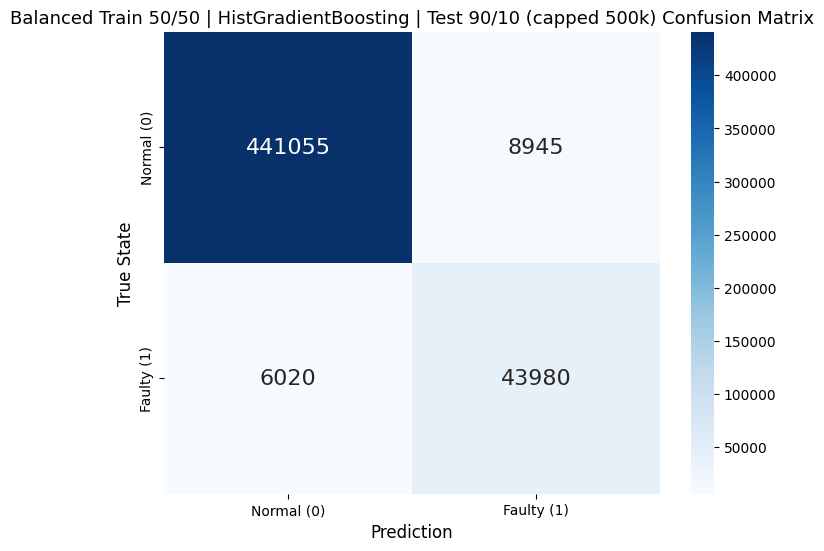

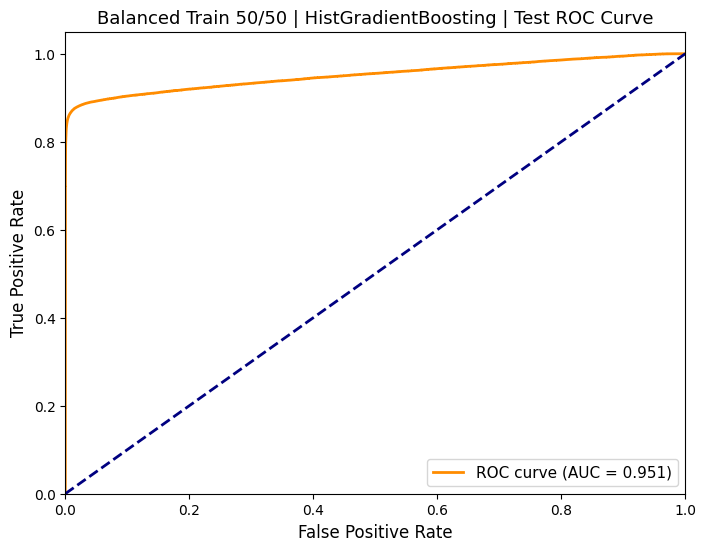

Classification Report (Test):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.98    450000
  Faulty (1)       0.83      0.88      0.85     50000

    accuracy                           0.97    500000
   macro avg       0.91      0.93      0.92    500000
weighted avg       0.97      0.97      0.97    500000


=== Balanced Train 50/50 | XGBoost ===
Training complete in 40.7s
Model saved to: /Users/dawoodbutt/Desktop/10. UNI/6. AI for Industry/AIFI_Group_Project/models/final/binary_champion_xgboost_balanced_50_50.joblib
Tuning threshold on validation set...
Chosen threshold=0.42 recall=0.901 missed_fault=0.099 false_alarm=0.030 [recall>90% AND FAR<50%]
Evaluating on capped test set (90/10)...


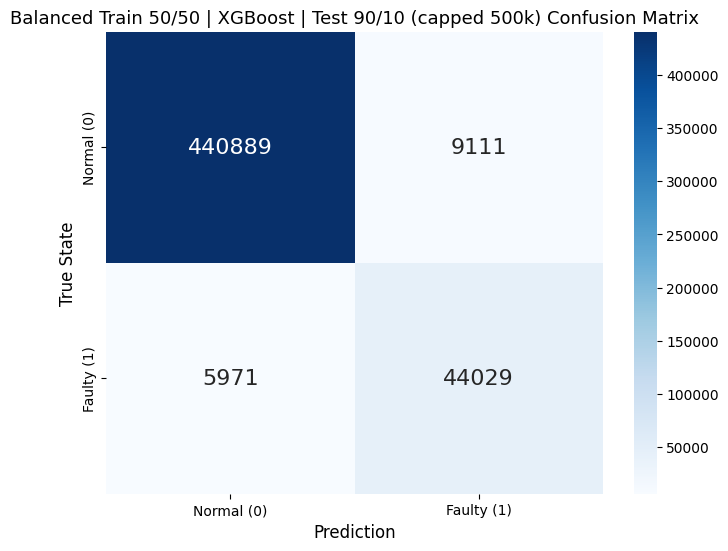

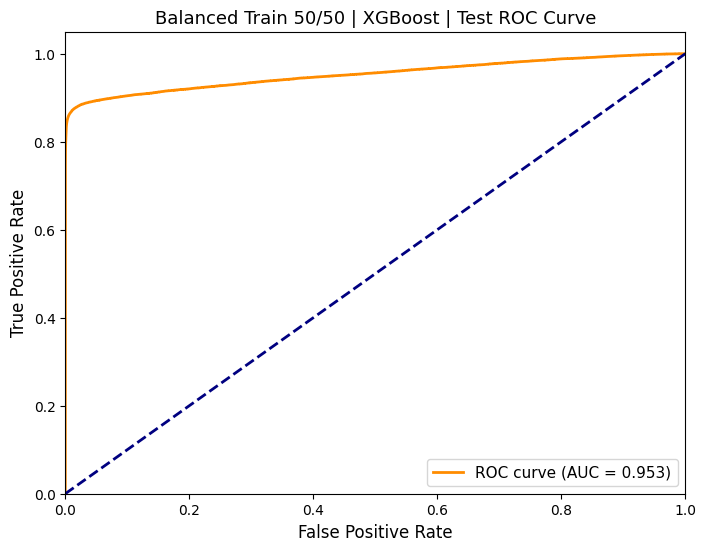

Classification Report (Test):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.98    450000
  Faulty (1)       0.83      0.88      0.85     50000

    accuracy                           0.97    500000
   macro avg       0.91      0.93      0.92    500000
weighted avg       0.97      0.97      0.97    500000


=== Imbalanced Train 90/10 (class_weight balanced) | HistGradientBoosting ===
Training complete in 39.1s
Model saved to: /Users/dawoodbutt/Desktop/10. UNI/6. AI for Industry/AIFI_Group_Project/models/final/binary_champion_hist_gradient_boosting_imbalanced_90_10.joblib
Tuning threshold on validation set...
Chosen threshold=0.42 recall=0.901 missed_fault=0.099 false_alarm=0.027 [recall>90% AND FAR<50%]
Evaluating on capped test set (90/10)...


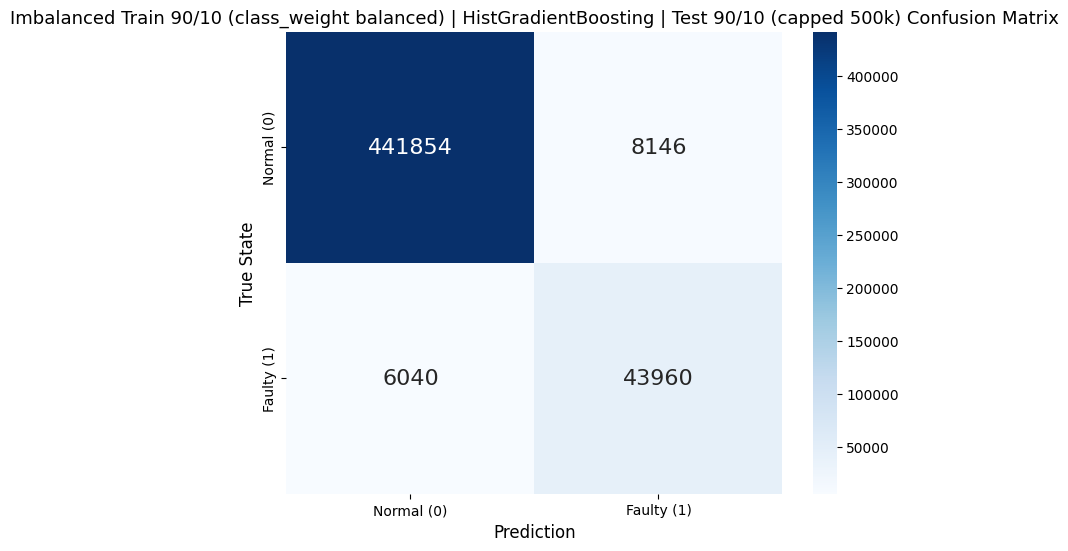

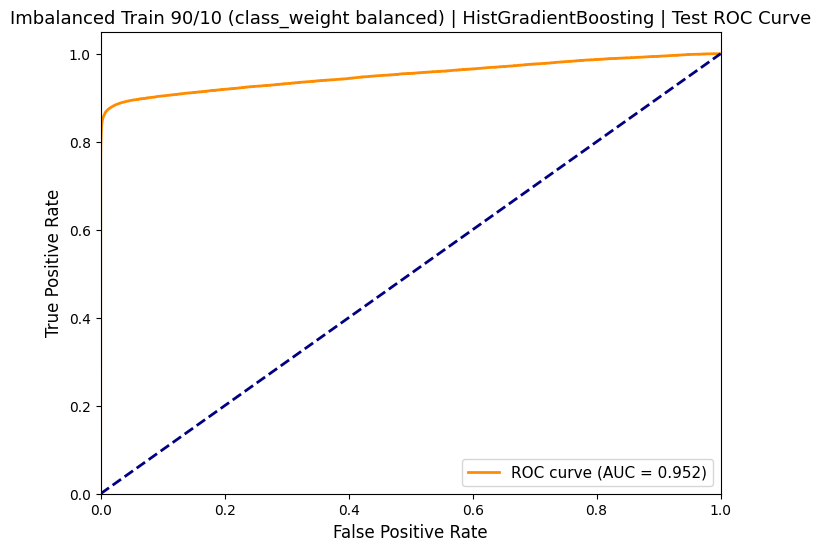

Classification Report (Test):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.98    450000
  Faulty (1)       0.84      0.88      0.86     50000

    accuracy                           0.97    500000
   macro avg       0.92      0.93      0.92    500000
weighted avg       0.97      0.97      0.97    500000


=== Imbalanced Train 90/10 (class_weight balanced) | XGBoost ===
Training complete in 23.9s
Model saved to: /Users/dawoodbutt/Desktop/10. UNI/6. AI for Industry/AIFI_Group_Project/models/final/binary_champion_xgboost_imbalanced_90_10.joblib
Tuning threshold on validation set...
Chosen threshold=0.42 recall=0.902 missed_fault=0.098 false_alarm=0.028 [recall>90% AND FAR<50%]
Evaluating on capped test set (90/10)...


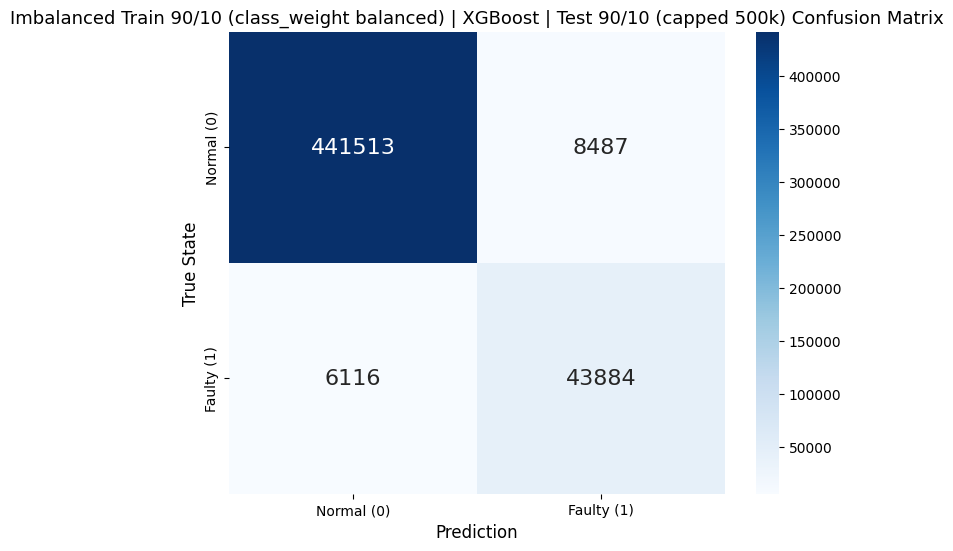

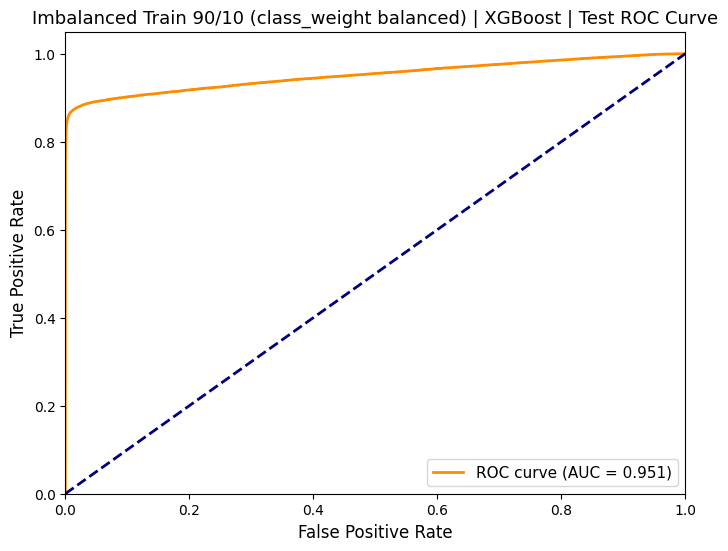

Classification Report (Test):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.98    450000
  Faulty (1)       0.84      0.88      0.86     50000

    accuracy                           0.97    500000
   macro avg       0.91      0.93      0.92    500000
weighted avg       0.97      0.97      0.97    500000



,model,config,threshold,roc_auc,recall,precision,f1,false_alarm_rate,missed_fault_rate
0,HistGradientBoosting,Balanced Train 50/50,0.42,0.951494,0.87960,0.830987,0.854603,0.019878,0.12040
1,XGBoost,Balanced Train 50/50,0.42,0.952851,0.88058,0.828547,0.853772,0.020247,0.11942
2,HistGradientBoosting,Imbalanced Train 90/10 (class_weight balanced),0.42,0.951600,0.87920,0.843665,0.861066,0.018102,0.12080
3,XGBoost,Imbalanced Train 90/10 (class_weight balanced),0.42,0.950954,0.87768,0.837945,0.857352,0.018860,0.12232


In [4]:
model_dir = PROJECT_ROOT / "models" / "final"
model_dir.mkdir(parents=True, exist_ok=True)

results_summary = []
trained_models = {}

model_specs = [
    {
        "name": "hist_gradient_boosting",
        "label": "HistGradientBoosting",
        "build": lambda class_weight: HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.05, max_depth=6,
            min_samples_leaf=20, class_weight=class_weight,
            random_state=RANDOM_STATE, verbose=0
        ),
    },
    {
        "name": "xgboost",
        "label": "XGBoost",
        "build": lambda class_weight: XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=6,
            random_state=RANDOM_STATE, eval_metric="logloss",
            tree_method="hist", verbosity=0
        ),
    },
]

for cfg_name, data in splits.items():
    label = data["label"]
    class_weight = data["class_weight"]
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val = data["X_val"]
    y_val = data["y_val"]

    for model_spec in model_specs:
        model_key = model_spec["name"]
        model_label = model_spec["label"]

        print(f"\n=== {label} | {model_label} ===")
        t0 = time.time()
        model = model_spec["build"](class_weight)
        fit_kwargs = {}
        if model_key == "xgboost" and class_weight == "balanced":
            fit_kwargs["sample_weight"] = compute_sample_weight(
                class_weight="balanced", y=y_train
            )
        model.fit(X_train, y_train, **fit_kwargs)
        print(f"Training complete in {time.time() - t0:.1f}s")

        model_path = model_dir / f"binary_champion_{model_key}_{cfg_name}.joblib"
        joblib.dump(model, model_path)
        print(f"Model saved to: {model_path}")

        print("Tuning threshold on validation set...")
        val_prob = model.predict_proba(X_val)[:, 1]
        rows = []
        for thr in np.arange(MIN_THRESHOLD, 0.96, 0.02):
            pred = (val_prob >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
            rows.append({
                "threshold": round(float(thr), 2),
                "recall": round(recall_score(y_val, pred, zero_division=0), 4),
                "precision": round(precision_score(y_val, pred, zero_division=0), 4),
                "f1": round(f1_score(y_val, pred, zero_division=0), 4),
                "false_alarm_rate": round(fp / (fp + tn) if (fp + tn) else 0, 4),
                "missed_fault_rate": round(fn / (fn + tp) if (fn + tp) else 0, 4),
            })
        thr_df = pd.DataFrame(rows)

        feasible_both = thr_df[
            (thr_df["missed_fault_rate"] <= MISSED_FAULT_TARGET)
            & (thr_df["false_alarm_rate"] <= MAX_FAR_ALLOWED)
        ]
        feasible_recall = thr_df[thr_df["missed_fault_rate"] <= MISSED_FAULT_TARGET]

        if len(feasible_both) > 0:
            chosen_threshold = float(feasible_both["threshold"].max())
            strategy = "recall>90% AND FAR<50%"
        elif len(feasible_recall) > 0:
            chosen_threshold = float(feasible_recall["threshold"].max())
            strategy = "recall>90% only"
        else:
            chosen_threshold = float(thr_df.loc[thr_df["missed_fault_rate"].idxmin(), "threshold"])
            strategy = "best recall available"

        row = thr_df[thr_df["threshold"] == chosen_threshold].iloc[0]
        print(
            f"Chosen threshold={chosen_threshold:.2f} "
            f"recall={row['recall']:.3f} "
            f"missed_fault={row['missed_fault_rate']:.3f} "
            f"false_alarm={row['false_alarm_rate']:.3f} "
            f"[{strategy}]"
        )

        print("Evaluating on capped test set (90/10)...")
        test_prob = model.predict_proba(X_test)[:, 1]
        test_pred = (test_prob >= chosen_threshold).astype(int)

        cm = confusion_matrix(y_test, test_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal (0)", "Faulty (1)"],
            yticklabels=["Normal (0)", "Faulty (1)"],
            annot_kws={"size": 16}
        )
        plt.title(f"{label} | {model_label} | Test 90/10 (capped 500k) Confusion Matrix", fontsize=13)
        plt.ylabel("True State", fontsize=12)
        plt.xlabel("Prediction", fontsize=12)
        plt.show()

        fpr, tpr, thresholds = roc_curve(y_test, test_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate", fontsize=12)
        plt.ylabel("True Positive Rate", fontsize=12)
        plt.title(f"{label} | {model_label} | Test ROC Curve", fontsize=13)
        plt.legend(loc="lower right", fontsize=11)
        plt.show()

        precision = precision_score(y_test, test_pred, zero_division=0)
        recall = recall_score(y_test, test_pred, zero_division=0)
        f1 = f1_score(y_test, test_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
        far = fp / (fp + tn) if (fp + tn) else 0
        missed = fn / (fn + tp) if (fn + tp) else 0

        print("Classification Report (Test):")
        print(classification_report(y_test, test_pred, target_names=["Normal (0)", "Faulty (1)"]))

        results_summary.append({
            "model": model_label,
            "config": label,
            "threshold": chosen_threshold,
            "roc_auc": roc_auc,
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "false_alarm_rate": far,
            "missed_fault_rate": missed,
        })

        artifacts = {
            "model_name": f"binary_champion_{model_key}_{cfg_name}",
            "model": model_label,
            "config": label,
            "threshold": chosen_threshold,
            "windows": ROLLING_WINDOWS,
            "features": MODEL_FEATURE_COLS,
            "threshold_tuning": thr_df.to_dict(orient="records"),
            "roc": {
                "fpr": fpr.tolist(),
                "tpr": tpr.tolist(),
                "thresholds": thresholds.tolist(),
                "auc": roc_auc,
            },
            "confusion_matrix": cm.tolist(),
            "classification_report": classification_report(
                y_test, test_pred, output_dict=True
            ),
        }

        with (model_dir / f"binary_artifacts_{model_key}_{cfg_name}.json").open("w") as f:
            json.dump(artifacts, f)

        trained_models[f"{model_key}_{cfg_name}"] = model

if results_summary:
    results_df = pd.DataFrame(results_summary)
    display(results_df)


THRESHOLD ANALYSIS: Impact on Recall, Precision, F1, FAR, and Missed Faults


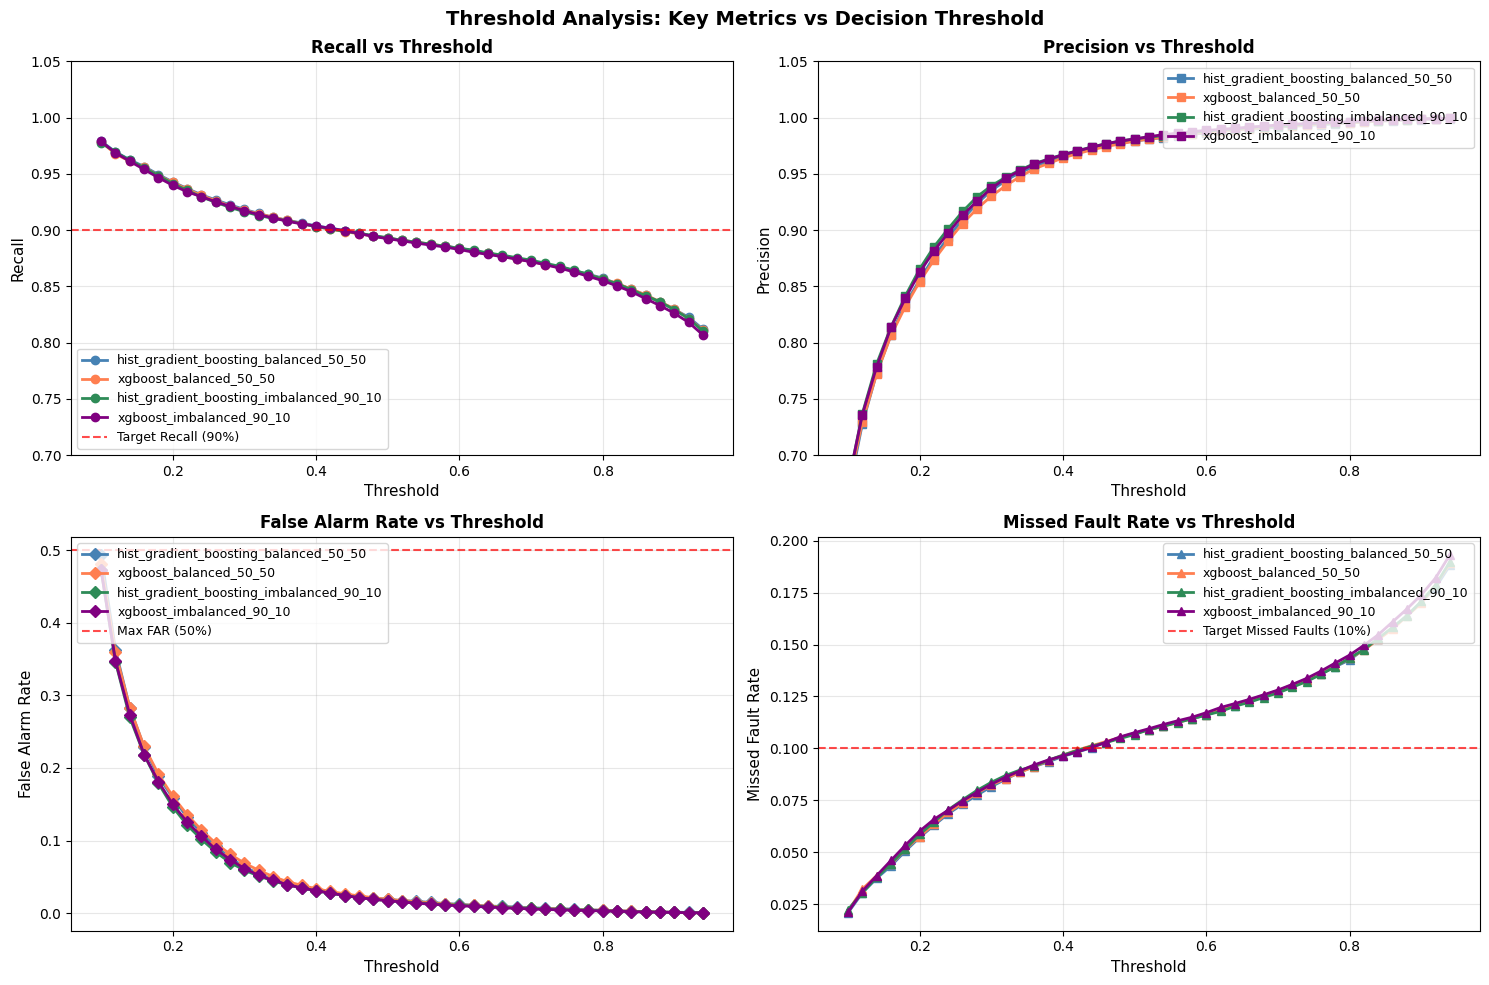


THRESHOLD SUMMARY: Chosen thresholds and their validation metrics


,Model,Config,Threshold,Recall,Precision,F1,FAR,Missed
0,hist,gradient_boosting_balanced_50_50,0.42,0.9018,0.9696,0.9345,0.0283,0.0982
1,xgboost,balanced_50_50,0.42,0.9008,0.9679,0.9331,0.0299,0.0992
2,hist,gradient_boosting_imbalanced_90_10,0.42,0.9010,0.9705,0.9344,0.0274,0.0990
3,xgboost,imbalanced_90_10,0.42,0.9016,0.9703,0.9347,0.0276,0.0984



OPERATING REGIONS: Threshold ranges meeting constraints

hist_gradient_boosting_balanced_50_50:
  Valid threshold range: 0.10 - 0.42
  Recall at min threshold:  0.9791
  Recall at max threshold:  0.9018
  FAR range: 0.0283 - 0.4935

xgboost_balanced_50_50:
  Valid threshold range: 0.10 - 0.42
  Recall at min threshold:  0.9784
  Recall at max threshold:  0.9008
  FAR range: 0.0299 - 0.4808

hist_gradient_boosting_imbalanced_90_10:
  Valid threshold range: 0.10 - 0.42
  Recall at min threshold:  0.9776
  Recall at max threshold:  0.9010
  FAR range: 0.0274 - 0.4725

xgboost_imbalanced_90_10:
  Valid threshold range: 0.10 - 0.42
  Recall at min threshold:  0.9788
  Recall at max threshold:  0.9016
  FAR range: 0.0276 - 0.4724


In [5]:
print("=" * 80)
print("THRESHOLD ANALYSIS: Impact on Recall, Precision, F1, FAR, and Missed Faults")
print("=" * 80)

# Collect all threshold tuning data for comparison
thr_analysis_data = {}

for cfg_name, data in splits.items():
    label = data["label"]
    X_val = data["X_val"]
    y_val = data["y_val"]
    
    for model_spec in model_specs:
        model_key = model_spec["name"]
        model_label = model_spec["label"]
        config_key = f"{model_key}_{cfg_name}"
        
        model = trained_models[config_key]
        val_prob = model.predict_proba(X_val)[:, 1]
        
        rows = []
        for thr in np.arange(MIN_THRESHOLD, 0.96, 0.02):
            pred = (val_prob >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
            rows.append({
                "threshold": round(float(thr), 2),
                "recall": round(recall_score(y_val, pred, zero_division=0), 4),
                "precision": round(precision_score(y_val, pred, zero_division=0), 4),
                "f1": round(f1_score(y_val, pred, zero_division=0), 4),
                "false_alarm_rate": round(fp / (fp + tn) if (fp + tn) else 0, 4),
                "missed_fault_rate": round(fn / (fn + tp) if (fn + tp) else 0, 4),
            })
        thr_df = pd.DataFrame(rows)
        thr_analysis_data[config_key] = thr_df

# Plot 1: Recall vs Threshold for all configs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Threshold Analysis: Key Metrics vs Decision Threshold", fontsize=14, fontweight="bold")

configs_list = list(thr_analysis_data.keys())
colors = ["steelblue", "coral", "seagreen", "purple"]

# Recall
ax = axes[0, 0]
for (config_key, thr_df), color in zip(thr_analysis_data.items(), colors):
    ax.plot(thr_df["threshold"], thr_df["recall"], marker="o", label=config_key, color=color, linewidth=2)
ax.axhline(0.90, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Target Recall (90%)")
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Recall vs Threshold", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.3)
ax.set_ylim([0.7, 1.05])

# Precision
ax = axes[0, 1]
for (config_key, thr_df), color in zip(thr_analysis_data.items(), colors):
    ax.plot(thr_df["threshold"], thr_df["precision"], marker="s", label=config_key, color=color, linewidth=2)
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision vs Threshold", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
ax.set_ylim([0.7, 1.05])

# False Alarm Rate
ax = axes[1, 0]
for (config_key, thr_df), color in zip(thr_analysis_data.items(), colors):
    ax.plot(thr_df["threshold"], thr_df["false_alarm_rate"], marker="D", label=config_key, color=color, linewidth=2)
ax.axhline(0.50, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Max FAR (50%)")
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("False Alarm Rate", fontsize=11)
ax.set_title("False Alarm Rate vs Threshold", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

# Missed Fault Rate
ax = axes[1, 1]
for (config_key, thr_df), color in zip(thr_analysis_data.items(), colors):
    ax.plot(thr_df["threshold"], thr_df["missed_fault_rate"], marker="^", label=config_key, color=color, linewidth=2)
ax.axhline(0.10, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Target Missed Faults (10%)")
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Missed Fault Rate", fontsize=11)
ax.set_title("Missed Fault Rate vs Threshold", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("THRESHOLD SUMMARY: Chosen thresholds and their validation metrics")
print("=" * 80)

summary_rows = []
for config_key, thr_df in thr_analysis_data.items():
    model_label = config_key.split("_")[0]
    cfg_label = "_".join(config_key.split("_")[1:])
    
    # Find chosen threshold (same logic as training)
    feasible_both = thr_df[
        (thr_df["missed_fault_rate"] <= MISSED_FAULT_TARGET)
        & (thr_df["false_alarm_rate"] <= MAX_FAR_ALLOWED)
    ]
    feasible_recall = thr_df[thr_df["missed_fault_rate"] <= MISSED_FAULT_TARGET]
    
    if len(feasible_both) > 0:
        chosen_thr = float(feasible_both["threshold"].max())
    elif len(feasible_recall) > 0:
        chosen_thr = float(feasible_recall["threshold"].max())
    else:
        chosen_thr = float(thr_df.loc[thr_df["missed_fault_rate"].idxmin(), "threshold"])
    
    row = thr_df[thr_df["threshold"] == chosen_thr].iloc[0]
    summary_rows.append({
        "Model": model_label,
        "Config": cfg_label,
        "Threshold": chosen_thr,
        "Recall": row["recall"],
        "Precision": row["precision"],
        "F1": row["f1"],
        "FAR": row["false_alarm_rate"],
        "Missed": row["missed_fault_rate"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Find the operating region for each model
print("\n" + "=" * 80)
print("OPERATING REGIONS: Threshold ranges meeting constraints")
print("=" * 80)

for config_key, thr_df in thr_analysis_data.items():
    feasible = thr_df[
        (thr_df["missed_fault_rate"] <= MISSED_FAULT_TARGET)
        & (thr_df["false_alarm_rate"] <= MAX_FAR_ALLOWED)
    ]
    
    if len(feasible) > 0:
        print(f"\n{config_key}:")
        print(f"  Valid threshold range: {feasible['threshold'].min():.2f} - {feasible['threshold'].max():.2f}")
        print(f"  Recall at min threshold:  {feasible.iloc[0]['recall']:.4f}")
        print(f"  Recall at max threshold:  {feasible.iloc[-1]['recall']:.4f}")
        print(f"  FAR range: {feasible['false_alarm_rate'].min():.4f} - {feasible['false_alarm_rate'].max():.4f}")
    else:
        print(f"\n{config_key}: ⚠ No valid threshold meets both constraints")
        best_recall = thr_df.loc[thr_df["missed_fault_rate"].idxmin()]
        print(f"  Best recall available at threshold {best_recall['threshold']:.2f}: recall={best_recall['recall']:.4f}, FAR={best_recall['false_alarm_rate']:.4f}")
